## Оптимизация гиперпараметров

### Классная работа

In [41]:
pip install optuna

   ---------------------------------------- 0.0/419.5 kB ? eta -:--:--
   -- ------------------------------------- 30.7/419.5 kB 1.4 MB/s eta 0:00:01
   ---------- ----------------------------- 112.6/419.5 kB 1.7 MB/s eta 0:00:01
   ------------------------ --------------- 256.0/419.5 kB 2.3 MB/s eta 0:00:01
   ---------------------------------------  409.6/419.5 kB 2.3 MB/s eta 0:00:01
   ---------------------------------------- 419.5/419.5 kB 2.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/263.9 kB ? eta -:--:--
   ---------------------------------------- 263.9/263.9 kB 8.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/78.5 kB ? eta -:--:--
   ---------------------------------------- 78.5/78.5 kB 4.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.datasets import make_classification, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, f1_score
from sklearn.linear_model import ElasticNet, SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.svm import SVC

from scipy.stats import uniform, loguniform, randint

import warnings
warnings.filterwarnings('ignore')

In [18]:
X, Y = make_classification(n_samples=1000, n_classes=2, n_features=5, n_redundant=0, random_state=1)

In [20]:
X.shape, Y.shape

((1000, 5), (1000,))

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [24]:
X_train.shape, Y_train.shape

((800, 5), (800,))

In [26]:
X_test.shape, Y_test.shape

((200, 5), (200,))

In [28]:
names = ["Nearest_Neighbors", "Linear_SVM", "Polynomial_SVM", "RBF_SVM", "Gaussian_Process",
         "Gradient_Boosting", "Decision_Tree", "Extra_Trees", "Random_Forest", "Neural_Net", "AdaBoost",
         "Naive_Bayes", "QDA", "SGD"]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(kernel="poly", degree=3, C=0.025),
    SVC(kernel="rbf", C=1, gamma=2),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    GradientBoostingClassifier(n_estimators=100, learning_rate=1.0),
    DecisionTreeClassifier(max_depth=5),
    ExtraTreesClassifier(n_estimators=10, min_samples_split=2),
    RandomForestClassifier(max_depth=5, n_estimators=100),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(n_estimators=100),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    SGDClassifier(loss="hinge", penalty="l2")]

In [30]:
scores = []
for name, clf in zip(names, classifiers):
    clf.fit(X_train, Y_train)
    score = clf.score(X_test, Y_test)
    scores.append(score)

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [31]:
df = pd.DataFrame()
df['name'] = names
df['score'] = scores
df.sort_values(by=["score"], ascending=False, inplace=True)
df

,name,score
0,Nearest_Neighbors,0.870
9,Neural_Net,0.865
12,QDA,0.860
4,Gaussian_Process,0.855
7,Extra_Trees,0.850
8,Random_Forest,0.850
11,Naive_Bayes,0.850
1,Linear_SVM,0.840
6,Decision_Tree,0.825
13,SGD,0.825


In [32]:
cm = sns.light_palette("green", as_cmap=True)
s = df.style.background_gradient(cmap=cm)
s

,name,score
0,Nearest_Neighbors,0.870000
9,Neural_Net,0.865000
12,QDA,0.860000
4,Gaussian_Process,0.855000
7,Extra_Trees,0.850000
8,Random_Forest,0.850000
11,Naive_Bayes,0.850000
1,Linear_SVM,0.840000
6,Decision_Tree,0.825000
13,SGD,0.825000


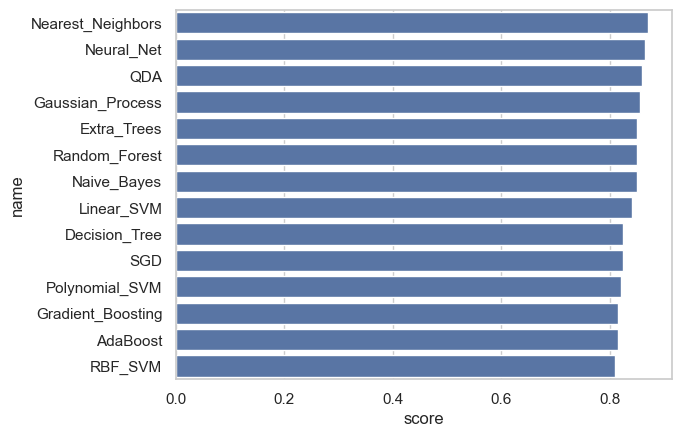

In [33]:
sns.set(style="whitegrid")
ax = sns.barplot(y="name", x="score", data=df)

#### Поиск по сетке

In [ ]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [ ]:
## Создаём X и y
X = df.drop('sales',axis=1)
y = df['sales']

# Разбиение на обучающий и тестовый наборы - TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Масштабирование данных (SCALE)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import ElasticNet

In [ ]:
help(ElasticNet)

Help on class ElasticNet in module sklearn.linear_model._coordinate_descent:

class ElasticNet(sklearn.base.MultiOutputMixin, sklearn.base.RegressorMixin, sklearn.linear_model._base.LinearModel)
 |  ElasticNet(alpha=1.0, *, l1_ratio=0.5, fit_intercept=True, precompute=False, max_iter=1000, copy_X=True, tol=0.0001, warm_start=False, positive=False, random_state=None, selection='cyclic')
 |
 |  Linear regression with combined L1 and L2 priors as regularizer.
 |
 |  Minimizes the objective function::
 |
 |          1 / (2 * n_samples) * ||y - Xw||^2_2
 |          + alpha * l1_ratio * ||w||_1
 |          + 0.5 * alpha * (1 - l1_ratio) * ||w||^2_2
 |
 |  If you are interested in controlling the L1 and L2 penalty
 |  separately, keep in mind that this is equivalent to::
 |
 |          a * ||w||_1 + 0.5 * b * ||w||_2^2
 |
 |  where::
 |
 |          alpha = a + b and l1_ratio = a / (a + b)
 |
 |  The parameter l1_ratio corresponds to alpha in the glmnet R package while
 |  alpha corresponds to

In [ ]:
base_elastic_model = ElasticNet()

In [ ]:
param_grid = {'alpha':[0.1,1,5,10,50,100],
              'l1_ratio':[.1, .5, .7, .9, .95, .99, 1]}

In [ ]:
# число verbose выбирайте сами
grid_model = GridSearchCV(estimator=base_elastic_model,
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error',
                          cv=5,
                          verbose=2)

In [ ]:
grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 42 candidates, totalling 210 fits
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.7; total time=   0.0s
[CV] END ............................alpha=0.1,

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.1, 1, 5, 10, 50, 100],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]},
             scoring='neg_mean_squared_error', verbose=2)

In [ ]:
grid_model.best_estimator_

ElasticNet(alpha=0.1, l1_ratio=1)

In [ ]:
y_pred = grid_model.predict(X_test)

In [ ]:
mean_squared_error(y_test,y_pred)

2.387342642087474

### Дополнительные задания

#### 1. При выборе модели мы обычно выбираем ту, которая дает наибольшее значение какой-то метрики. Но это означает, что эта оценка метрики уже становится завышенной. Поэтому для объективной оценки качества модели ее опять следует оценить на новом наборе данных. Поэтому для выбора модели нужно разделить выборку на три части - обучающую, валидационную и тестовую. Повторите первую часть работы, но с таким разбиением и получите несмещенную оценку качества наилучшей модели.

In [244]:
X, Y = make_classification(n_samples=1000, n_classes=2, n_features=5, n_redundant=0, random_state=1)
X.shape, Y.shape

((1000, 5), (1000,))

In [246]:
X_train, X_mid, y_train, y_mid = train_test_split(X, Y, train_size = 0.8, random_state = 42)
X_valid, X_test, y_valid, y_test = train_test_split(X_mid, y_mid, test_size = 0.5, random_state=42)

In [248]:
print('Train:', len(X_train))
print('Valid:', len(X_valid))
print('Test:', len(X_test))

Train: 800
Valid: 100
Test: 100


In [250]:
names = ["Nearest_Neighbors", "Linear_SVM", "Polynomial_SVM", "RBF_SVM", "Gaussian_Process",
         "Gradient_Boosting", "Decision_Tree", "Extra_Trees", "Random_Forest", "Neural_Net", "AdaBoost",
         "Naive_Bayes", "QDA", "SGD"]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(kernel="poly", degree=3, C=0.025),
    SVC(kernel="rbf", C=1, gamma=2),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    GradientBoostingClassifier(n_estimators=100, learning_rate=1.0),
    DecisionTreeClassifier(max_depth=5),
    ExtraTreesClassifier(n_estimators=10, min_samples_split=2),
    RandomForestClassifier(max_depth=5, n_estimators=100),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(n_estimators=100),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    SGDClassifier(loss="hinge", penalty="l2")
]

Оценка на валидационной выборке

In [253]:
val_scores = []
for name, clf in zip(names, classifiers):
    
    clf.fit(X_train, y_train)
    score = clf.score(X_valid, y_valid)
    
    val_scores.append(score)

In [255]:
best_idx = np.argmax(val_scores)
best_name = names[best_idx]
best_model = classifiers[best_idx]

In [257]:
print(f'Лучшая модель на валидации: {best_name}')
print(f'Её точность на валидации: {val_scores[best_idx]:.4f}')

Лучшая модель на валидации: Gaussian_Process
Её точность на валидации: 0.8900


In [259]:
print(f'Score: {best_model.score(X_test, y_test)}')

Score: 0.87


In [261]:
y_test_pred = best_model.predict(X_test)
print(f'F1: {f1_score(y_test, y_test_pred)}')

F1: 0.8686868686868687


In [263]:
df = pd.DataFrame({'name': names, 'score': val_scores})
df.sort_values(by="score", ascending=False, inplace=True)
df

,name,score
4,Gaussian_Process,0.89
0,Nearest_Neighbors,0.87
7,Extra_Trees,0.87
9,Neural_Net,0.87
3,RBF_SVM,0.86
5,Gradient_Boosting,0.86
8,Random_Forest,0.86
10,AdaBoost,0.85
1,Linear_SVM,0.84
6,Decision_Tree,0.84


In [265]:
cm = sns.light_palette("green", as_cmap=True)
styled = df.style.background_gradient(cmap=cm)
styled

,name,score
4,Gaussian_Process,0.890000
0,Nearest_Neighbors,0.870000
7,Extra_Trees,0.870000
9,Neural_Net,0.870000
3,RBF_SVM,0.860000
5,Gradient_Boosting,0.860000
8,Random_Forest,0.860000
10,AdaBoost,0.850000
1,Linear_SVM,0.840000
6,Decision_Tree,0.840000


#### 2. Оптимизируйте гиперпараметры той же модели, но другим методом - случайным поиском. Сравните полученные результаты.

In [105]:
rf = RandomForestClassifier(random_state=42)

In [111]:
param_distributions = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'criterion': ['gini', 'entropy']
}

In [113]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [115]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E10825AF00>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E108399CD0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E1039DFAD0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E103C256A0>},
                   random_state=42, scoring='accuracy', verbose=1)

In [117]:
print(f'Лучшие параметры (RandomizedSearch): {random_search.best_params_}')
print(f'Лучшая точность на кросс-валидации: {random_search.best_score_:.4f}')

Лучшие параметры (RandomizedSearch): {'criterion': 'gini', 'max_depth': 14, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 63}
Лучшая точность на кросс-валидации: 0.8600


In [119]:
y_pred = random_search.predict(X_test)
test_acc = random_search.score(X_test, y_test)
f1 = f1_score(y_test, y_pred, average='macro')

In [121]:
print(f'Точность на тесте: {test_acc:.4f}')
print(f'F1 (macro) на тесте: {f1:.4f}')

Точность на тесте: 0.8700
F1 (macro) на тесте: 0.8700


#### 3.Во второй задаче найдите наиболее эффективный класс моделей, а затем оптимизируйте гиперпараметры у этой модели. Сравните, насколько лучше получилась модель.

In [123]:
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)
base_score = rf_base.score(X_valid, y_valid)

In [137]:
print(f'Базовый случайный лес на валидации: {base_score:.4f}')

Базовый случайный лес на валидации: 0.8500


In [127]:
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [129]:
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [131]:
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='accuracy')

In [135]:
print(f'Лучшие параметры (GridSearch): {grid_rf.best_params_}')
print(f'Лучшая точность на кросс-валидации: {grid_rf.best_score_:.4f}')

Лучшие параметры (GridSearch): {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}
Лучшая точность на кросс-валидации: 0.8613


In [139]:
test_acc_grid = grid_rf.score(X_test, y_test)
print(f'Точность на тесте после подбора: {test_acc_grid:.4f}')

Точность на тесте после подбора: 0.8700


#### 4. Выберите любой датасет. Обучите несколько моделей. На лучшей модели подберите гиперпараметры с помощью библиотек Optuna или Hyperopt (дополнительно)

In [204]:
data = load_wine()
X = data.data
y = data.target

In [206]:
X_train, X_test, y_train, y_test, = train_test_split(X, y, train_size = 0.8, random_state = 42)

In [208]:
print('Train:', len(X_train))
print('Test:', len(X_test))

Train: 142
Test: 36


In [210]:
names = ["Nearest_Neighbors", "Linear_SVM", "Polynomial_SVM", "RBF_SVM", "Gaussian_Process",
         "Gradient_Boosting", "Decision_Tree", "Extra_Trees", "Random_Forest", "Neural_Net", "AdaBoost",
         "Naive_Bayes", "QDA", "SGD"]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(kernel="poly", degree=3, C=0.025),
    SVC(kernel="rbf", C=1, gamma=2),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    GradientBoostingClassifier(n_estimators=100, learning_rate=1.0),
    DecisionTreeClassifier(max_depth=5),
    ExtraTreesClassifier(n_estimators=10, min_samples_split=2),
    RandomForestClassifier(max_depth=5, n_estimators=100),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(n_estimators=100),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    SGDClassifier(loss="hinge", penalty="l2")
]

In [212]:
model_names = []
mean_scores = []
std_scores = []

for name, clf in zip(names, classifiers):
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    std_score = scores.std()
    
    model_names.append(name)
    mean_scores.append(mean_score)
    std_scores.append(std_score)

In [214]:
df_results = pd.DataFrame({
    'Model': model_names,
    'Mean Accuracy': mean_scores,
    'Std': std_scores
})

In [216]:
df_results.sort_values(by='Mean Accuracy', ascending=False, inplace=True)
df_results.reset_index(drop=True, inplace=True)

In [218]:
df_results['Mean Accuracy'] = df_results['Mean Accuracy'].apply(lambda x: f"{x:.4f}")
df_results['Std'] = df_results['Std'].apply(lambda x: f"{x:.4f}")

In [220]:
cm = sns.light_palette("green", as_cmap=True)
styled_df = df_results.style.background_gradient(subset=['Mean Accuracy'], cmap=cm)

In [222]:
styled_df

,Model,Mean Accuracy,Std
0,Extra_Trees,0.9791,0.0277
1,QDA,0.9791,0.0277
2,Random_Forest,0.9645,0.0319
3,Naive_Bayes,0.9645,0.0391
4,Linear_SVM,0.9505,0.0282
5,Gradient_Boosting,0.9505,0.0366
6,AdaBoost,0.9224,0.0148
7,Decision_Tree,0.9153,0.0183
8,Gaussian_Process,0.9086,0.0273
9,Neural_Net,0.6825,0.2180


In [224]:
best_idx = np.argmax(cv_scores)
best_name = names[best_idx]

In [226]:
print(f'Лучшая модель на кросс-валидации: {best_name} с точностью {cv_scores[best_idx]:.4f}')

Лучшая модель на кросс-валидации: QDA с точностью 0.9791


Для демонстрации Optuna возьмём DecisionTreeClassifier

In [229]:
def objective(trial):
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 2, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    
    clf = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    
    score = cross_val_score(clf, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

In [231]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-03-19 01:17:52,600] A new study created in memory with name: no-name-9fb4cdd3-672d-413f-a256-7908a920bdb4


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-19 01:17:52,634] Trial 0 finished with value: 0.9153368794326241 and parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.9153368794326241.
[I 2026-03-19 01:17:52,657] Trial 1 finished with value: 0.8809101654846335 and parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.9153368794326241.
[I 2026-03-19 01:17:52,716] Trial 2 finished with value: 0.9222813238770685 and parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 1}. Best is trial 2 with value: 0.9222813238770685.
[I 2026-03-19 01:17:52,754] Trial 3 finished with value: 0.9086879432624113 and parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 2 with value: 0.9222813238770685.
[I 2026-03-19 01:17:52,777] Trial 4 finished with value: 0.8738179669030733 and parameter

In [232]:
print(f'Лучшее значение accuracy: {study.best_value:.4f}')
print(f'Лучшие гиперпараметры: {study.best_params}')

Лучшее значение accuracy: 0.9224
Лучшие гиперпараметры: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 5}


In [235]:
best_params = study.best_params

final_tree = DecisionTreeClassifier(**best_params, random_state=42)
final_tree.fit(X_train, y_train)

test_acc = final_tree.score(X_test, y_test)

In [237]:
print(f'Точность на тесте с оптимизированным деревом: {test_acc:.4f}')

Точность на тесте с оптимизированным деревом: 0.9444
